# BPIC 2012: Exploratory Data Analysis

Verify that the BPIC 2012 event log matches the assumptions made in the Exposé (Section 3.6, E4) before any pipeline or model work begins.

BPIC 2012 originates from the same Dutch financial institution as BPIC 2017 but was recorded five years earlier. Reduced feature space (only `AMOUNT_REQ`, no offer attributes), Dutch `W_*` activity labels and inverse class imbalance (2,246 / 12,688 = 17.7%) make it a meaningful generalizability test.

> **Pitfall:** Each event in BPIC 2012 can appear up to three times under different `lifecycle:transition` values (`SCHEDULE`, `START`, `COMPLETE`). The preprocessing pipeline keeps only `COMPLETE` before target construction, prefix-length diagnostics and model-facing activity-token vocabularies. The raw activity-frequency plots below are only descriptive.

## 1: Load the XES Event Log

`pm4py` parses the XES into an event log object, then flattens to a Pandas DataFrame where each row is one event. Timestamps are cast to `datetime64[ns, UTC]`.

Expected: ~13,087 cases, ~262,200 events, date range 2011-10-01 -> 2012-03-14.


In [16]:
from pm4py.objects.log.importer.xes.variants import iterparse
from pm4py.util import constants
import pm4py
import pandas as pd
import warnings

# Disable pm4py warnings
constants.SHOW_PROGRESS_BAR = False
warnings.filterwarnings(
    "ignore",
    message="ISO8601 strings are not fully supported with strpfromiso*",
    category=UserWarning,
    module="pm4py.util.dt_parsing.parser",
)

# Load the BPIC 2012 XES and convert to a DataFrame
log = iterparse.apply("BPI Challenge 2012/BPI_Challenge_2012.xes")
df  = pm4py.convert_to_dataframe(log)
df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], utc=True)

# Compute case count, event count and time range
n_cases  = df["case:concept:name"].nunique()
n_events = len(df)
date_min = df["time:timestamp"].min()
date_max = df["time:timestamp"].max()

# Print summary statistics
print(f"Cases:     {n_cases:,}")
print(f"Events:    {n_events:,}")
print(f"Date range: {date_min.date()} → {date_max.date()}")
print(f"\nColumns:\n{df.columns.tolist()}")


Cases:     13,087
Events:    262,200
Date range: 2011-10-01 → 2012-03-14

Columns:
['org:resource', 'lifecycle:transition', 'concept:name', 'time:timestamp', 'case:REG_DATE', 'case:concept:name', 'case:AMOUNT_REQ']


## 2: Attribute Presence

BPIC 2012 has a reduced feature space compared to BPIC 2017.

- **Case attributes**: Constant within a trace, attached to every event:
`case:AMOUNT_REQ`, `case:REG_DATE`
- **Offer attributes**: none. `CreditScore`, `MonthlyCost`, `OfferedAmount`, `NumberOfTerms` do not exist in this log.

Consequence for the artifact: the encoder runs with `USE_OFFER_FEATURES=False` and non-IID partitioning focuses on a single dimension (`AMOUNT_REQ`).

In [17]:
# Define case attributes
CASE_ATTRS = ["case:AMOUNT_REQ", "case:REG_DATE"]

# Look for Null-values and count them
print("\nNULL COUNTS (event-level)")
print("-" * 70)
for col in CASE_ATTRS:
    n_null = df[col].isna().sum()
    pct    = 100 * n_null / len(df)
    print(f"  {col:<25} {n_null:>8,}  ({pct:5.1f}%)")

# Inspect AMOUNT_REQ distribution (one row per case; REG_DATE is descriptive)
print("\nCASE ATTRIBUTES: Value Distributions")
print("-" * 70)
cases  = df.drop_duplicates("case:concept:name")
amount = pd.to_numeric(cases["case:AMOUNT_REQ"], errors="coerce")
print(f"\ncase:AMOUNT_REQ  (n={amount.notna().sum():,})")
print(amount.describe().to_string())

# Confirm none of the BPIC 2017 features are present (sanity-check)
expected_missing = ["CreditScore", "MonthlyCost", "OfferedAmount", "NumberOfTerms", "case:LoanGoal", "case:ApplicationType"]
present = [c for c in expected_missing if c in df.columns]
print(f"\nBPIC 2017 attributes present in BPIC 2012: {present if present else 'none'}")



NULL COUNTS (event-level)
----------------------------------------------------------------------
  case:AMOUNT_REQ                  0  (  0.0%)
  case:REG_DATE                    0  (  0.0%)

CASE ATTRIBUTES: Value Distributions
----------------------------------------------------------------------

case:AMOUNT_REQ  (n=13,087)
count    13087.000000
mean     13573.356079
std      12226.692089
min          0.000000
25%       5000.000000
50%      10000.000000
75%      17620.000000
max      99999.000000

BPIC 2017 attributes present in BPIC 2012: none


#### AMOUNT_REQ Consistency

`AMOUNT_REQ` is the single partitioning attribute for BPIC 2012 on the case level. The non-IID routing assumes that the value is stable within a case. The check below verifies this invariant before zero-amount cases are routed separately.


In [18]:
# Count distinct AMOUNT_REQ values within each case
amount_nunique = df.groupby("case:concept:name")["case:AMOUNT_REQ"].nunique(dropna=False)
changed_cases = amount_nunique[amount_nunique > 1]
n_cases = df["case:concept:name"].nunique()

print(f"Cases with changing AMOUNT_REQ: {len(changed_cases):,} / {n_cases:,} ({len(changed_cases) / n_cases:.4%})")
if changed_cases.empty: print("AMOUNT_REQ is stable within every case.")
else:
    changed_ids = changed_cases.index[:10]
    changed_view = (
        df.loc[df["case:concept:name"].isin(changed_ids), ["case:concept:name", "time:timestamp", "case:AMOUNT_REQ"]]
        .drop_duplicates()
        .sort_values(["case:concept:name", "time:timestamp"])
    )
    print("Sample cases with changing AMOUNT_REQ:")
    print(changed_view.to_string(index=False))

Cases with changing AMOUNT_REQ: 0 / 13,087 (0.0000%)
AMOUNT_REQ is stable within every case.


## 3: Outcome Resolution

Terminal events define a target with three classes: `A_APPROVED` maps to class 2, `A_DECLINED` maps to class 1 and `A_CANCELLED` maps to class 0. We resolve duplicates by taking the **last** terminal event per case, identical to the BPIC 2017 procedure.

BPIC 2012 is skewed towards denial of loan applications. The later training stage uses multiclass cross-entropy loss. Class weights remain an experiment decision for the training scripts.

In [19]:
# Define outcome activities and mapping
OUTCOME_ACTIVITIES = ["A_APPROVED", "A_DECLINED", "A_CANCELLED"]
OUTCOME_MAPPING = {"A_APPROVED": 2, "A_DECLINED": 1, "A_CANCELLED": 0}

# Apply the COMPLETE filter before resolving BPIC 2012 outcomes
outcome_base = df[df["lifecycle:transition"] == "COMPLETE"].copy()

# Select recognized terminal events and keep the last one per case
ordered = outcome_base.sort_values(["case:concept:name", "time:timestamp"]).copy()
ordered["event_pos"] = ordered.groupby("case:concept:name").cumcount() + 1
outcome_events = ordered[ordered["concept:name"].isin(OUTCOME_ACTIVITIES)].copy()
outcome_counts = outcome_events.groupby("case:concept:name")["concept:name"].agg(["count", "nunique"])
last_outcome = (
    outcome_events.sort_values(["case:concept:name", "time:timestamp", "event_pos"])
    .groupby("case:concept:name")
    .tail(1)
    .set_index("case:concept:name")
)
last_outcome["outcome_class"] = last_outcome["concept:name"].map(OUTCOME_MAPPING).astype(int)

# Count outcome classes, repeated decision events and truncation cases
n_approved = int((last_outcome["concept:name"] == "A_APPROVED").sum())
n_declined = int((last_outcome["concept:name"] == "A_DECLINED").sum())
n_cancelled = int((last_outcome["concept:name"] == "A_CANCELLED").sum())
n_multi = int((outcome_counts["count"] > 1).sum())
n_multi_distinct = int((outcome_counts["nunique"] > 1).sum())
n_no_outcome = outcome_base["case:concept:name"].nunique() - len(last_outcome)

# Print the summary
print(f"Cases with >1 outcome event:      {n_multi:,}")
print(f"Cases with >1 outcome label:      {n_multi_distinct:,}")
print(f"Cases with A_APPROVED -> class 2: {n_approved:,}")
print(f"Cases with A_DECLINED -> class 1: {n_declined:,}")
print(f"Cases with A_CANCELLED -> class 0:{n_cancelled:,}")
print(f"Total with outcome event:         {len(last_outcome):,}")
print(f"Cases without outcome event:      {n_no_outcome:,}")

# Check if cases with no outcome concentrate near the log cutoff
no_outcome_ids = set(outcome_base["case:concept:name"].unique()) - set(last_outcome.index)
no_outcome_cases = outcome_base[outcome_base["case:concept:name"].isin(no_outcome_ids)]
print(no_outcome_cases.groupby("case:concept:name")["time:timestamp"].max().describe())

Cases with >1 outcome event:      0
Cases with >1 outcome label:      0
Cases with A_APPROVED -> class 2: 2,246
Cases with A_DECLINED -> class 1: 7,635
Cases with A_CANCELLED -> class 0:2,807
Total with outcome event:         12,688
Cases without outcome event:      399
count                                    399
mean     2012-03-10 00:34:11.696183040+00:00
min         2012-02-22 13:25:55.457000+00:00
25%      2012-03-08 17:18:19.662000128+00:00
50%      2012-03-09 20:48:54.088999936+00:00
75%      2012-03-13 16:53:36.643500032+00:00
max         2012-03-14 16:04:54.681000+00:00
Name: time:timestamp, dtype: object


#### Trace Cutting at the Decision Event

The preprocessing cuts every trace after the final recognized decision event. The decision event itself remains in the trace. BPIC 2012 keeps the `COMPLETE` lifecycle filter first, then creates `activity_token`, so `[END]` follows the decision event in the filtered event stream.


In [20]:
# Define outcome events
DECISION_OUTCOMES = ["A_APPROVED", "A_DECLINED", "A_CANCELLED"]

# Apply the COMPLETE filtering before the trace-cutting diagnostic
complete = df[df["lifecycle:transition"] == "COMPLETE"].copy()
ordered = complete.sort_values(["case:concept:name", "time:timestamp"]).copy()
ordered["event_pos"] = ordered.groupby("case:concept:name").cumcount()
ordered["activity_token"] = ordered["concept:name"].astype(str) + "+" + ordered["lifecycle:transition"].astype(str)
decision_events = ordered[ordered["concept:name"].isin(DECISION_OUTCOMES)].copy()
counts = decision_events.groupby("case:concept:name")["concept:name"].agg(["count", "nunique"])
last_decision = (
    decision_events.sort_values(["case:concept:name", "time:timestamp", "event_pos"])
    .groupby("case:concept:name")
    .tail(1)
    .rename(columns={"event_pos": "decision_pos", "time:timestamp": "decision_time"})
    .set_index("case:concept:name")
)

# Cut after the final decision event and validate the resulting NextActivity target
ordered["decision_pos"] = ordered["case:concept:name"].map(last_decision["decision_pos"])
has_decision = ordered["decision_pos"].notna()
keep = ~has_decision | (ordered["event_pos"] <= ordered["decision_pos"])
cut_events = ordered.loc[keep].copy()
cut_events["NextActivity"] = cut_events.groupby("case:concept:name")["activity_token"].shift(-1).fillna("[END]")

# Count removed events post-decision and validate the cut traces
removed = int((~keep).sum())
base = int(has_decision.sum())
share_removed = removed / base if base else 0.0

# Validate that no post-decision events remain and every cut trace ends with [END]
post_cut_remaining = int((cut_events["event_pos"] > cut_events["decision_pos"]).sum())
end_token_ok = bool(cut_events.groupby("case:concept:name")["NextActivity"].last().eq("[END]").all())

# Print the summary
print(f"Cases with a decision event:             {len(last_decision):,}")
print(f"Cases with >1 decision event:            {int((counts['count'] > 1).sum()):,}")
print(f"Cases with >1 distinct decision label:   {int((counts['nunique'] > 1).sum()):,}")
print(f"Events removed after decision:           {removed:,} ({share_removed:.2%} of events in decision cases)")
print(f"Events after decision in cut trace:      {post_cut_remaining:,}")
print(f"Last NextActivity is [END] for all cases: {end_token_ok}")

Cases with a decision event:             12,688
Cases with >1 decision event:            0
Cases with >1 distinct decision label:   0
Events removed after decision:           13,422 (8.55% of events in decision cases)
Events after decision in cut trace:      0
Last NextActivity is [END] for all cases: True


## 4: Activity Analysis

Activities follow a prefix convention: `A_` for application state changes, `O_` for offer events and `W_` for manual work items. This section describes the raw activity distribution before model-facing encoding.

Pre-processing creates lifecycle-aware activity tokens and next-activity targets. The model-facing vocabularies are built later in the shared prefix encoding step from the training split only, so validation and test activities cannot leak into the fitted indices. A reserved `[END]` token marks the end of each cut trace. Tokens unseen during vocabulary fitting are mapped to `[UNK]` during encoding.

Unique activities: 24

All activities:
concept:name
W_Completeren aanvraag            54850
W_Nabellen offertes               52016
W_Nabellen incomplete dossiers    25190
W_Valideren aanvraag              20809
W_Afhandelen leads                16566
A_SUBMITTED                       13087
A_PARTLYSUBMITTED                 13087
A_DECLINED                         7635
A_PREACCEPTED                      7367
O_SENT                             7030
O_CREATED                          7030
O_SELECTED                         7030
A_ACCEPTED                         5113
A_FINALIZED                        5015
O_CANCELLED                        3655
O_SENT_BACK                        3454
A_CANCELLED                        2807
A_REGISTERED                       2246
A_ACTIVATED                        2246
A_APPROVED                         2246
O_ACCEPTED                         2243
O_DECLINED                          802
W_Beoordelen fraude                 664
W_Wijzigen contractgegevens 

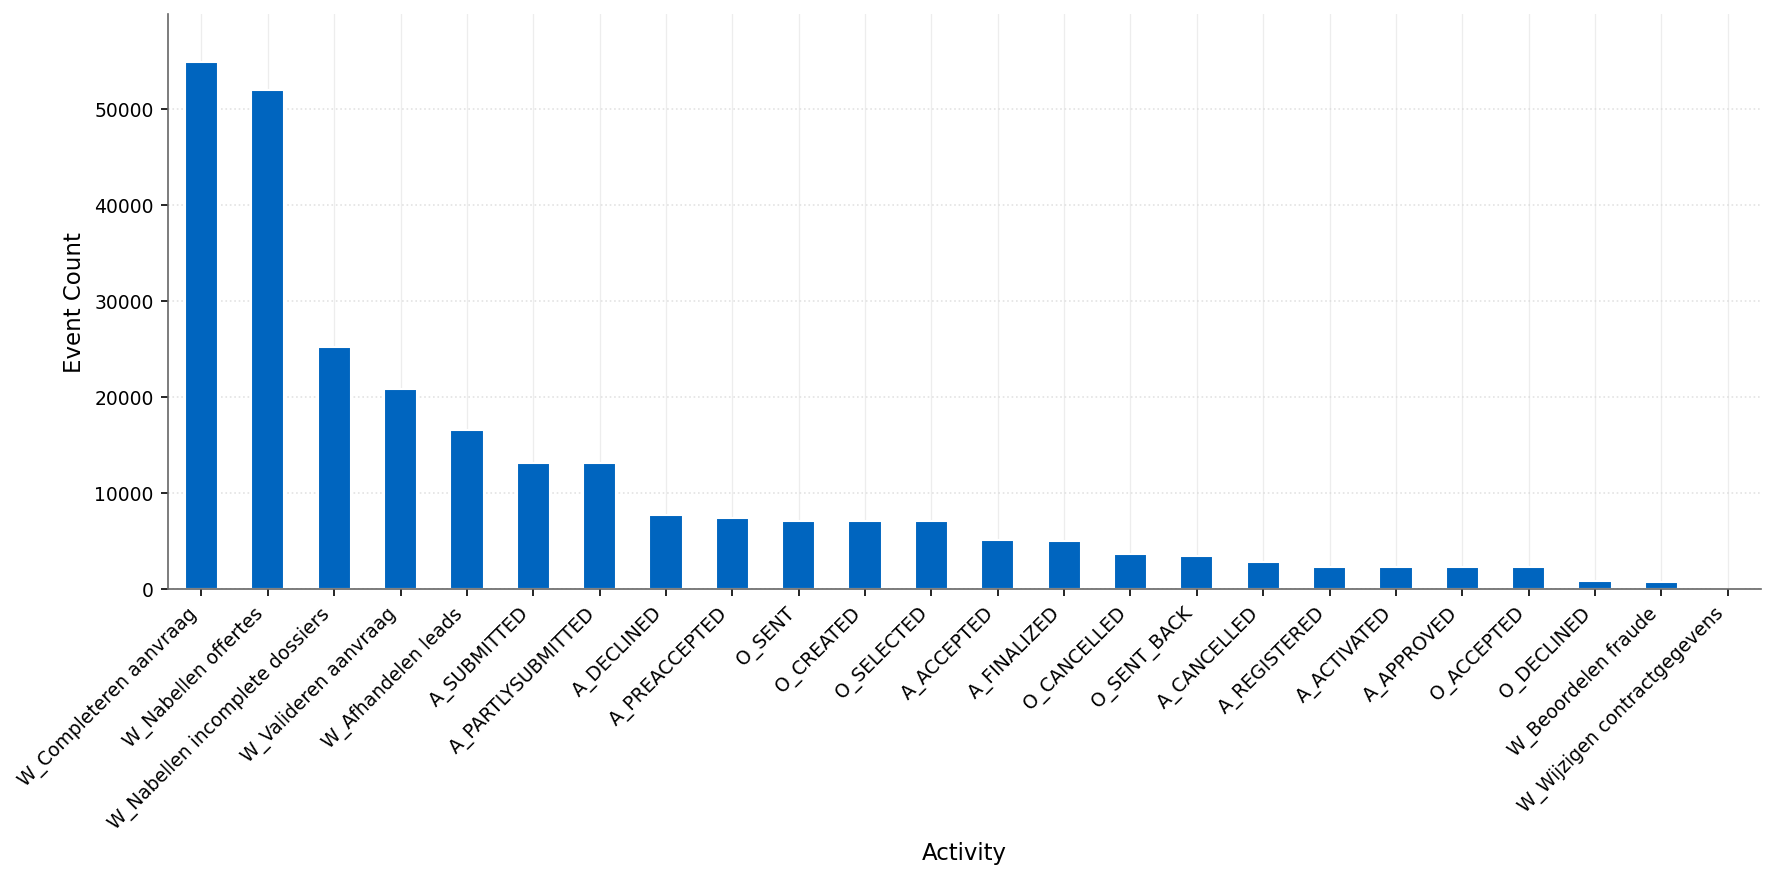

Saved: plots/B_01_activity_freq.png


In [21]:
import matplotlib.pyplot as plt
import os

# Figure colors (convention for grid, spine and legend)
GRID_COLOR  = "#d9d9d9"
SPINE_COLOR = "#666666"
LEGEND_EDGE = "#bfbfbf"

# HELPER: Figure grid and spine styling
def _style_non_pie_axes(ax_temp, x_margin=0.04):
    ax_temp.grid(False)
    ax_temp.grid(axis="x", linestyle="-", linewidth=0.6, color=GRID_COLOR, alpha=0.45)
    ax_temp.grid(axis="y", linestyle=":", linewidth=0.8, color=GRID_COLOR, alpha=0.75)
    ax_temp.set_axisbelow(True)
    ax_temp.margins(x=x_margin)
    ax_temp.spines["top"].set_visible(False)
    ax_temp.spines["right"].set_visible(False)
    for side in ("left", "bottom"):
        ax_temp.spines[side].set_color(SPINE_COLOR)
        ax_temp.spines[side].set_linewidth(0.8)

# HELPER: Figure legend styling
def _style_reference_legend(legend):
    frame = legend.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor(LEGEND_EDGE)
    frame.set_alpha(0.78)
    frame.set_linewidth(0.8)

# HELPER: Pad the top of the figure by a fraction of the figure height
def _pad_top(ax_temp, fraction=0.12):
    low, high = ax_temp.get_ylim()
    ax_temp.set_ylim(low, high + (high - low) * fraction)

# Set global figure parameters
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Create the plots directory if it doesn't exist and count activities
os.makedirs("plots", exist_ok=True)
activity_counts = df["concept:name"].value_counts()
print(f"Unique activities: {len(activity_counts)}")
print(f"\nAll activities:\n{activity_counts.to_string()}")

# Check dropped activity by the filter
after_filter = df[df["lifecycle:transition"] == "COMPLETE"]
missing_after_filter = set(df["concept:name"].unique()) - set(after_filter["concept:name"].unique())
print("Activities dropped by COMPLETE-only filter:", missing_after_filter)

# Create the activity frequency plot
fig, ax = plt.subplots(figsize=(12, 6))
activity_counts.plot(kind="bar", ax=ax, color="#0065BF", edgecolor="white")
ax.set_xlabel("Activity")
ax.set_ylabel("Event Count")
ax.tick_params(axis="x", labelrotation=45, labelsize=9)

# Right-align rotated labels so they hang from the tick, not center on it
for label in ax.get_xticklabels(): label.set_horizontalalignment("right")

# Apply axis styling and add headroom above the tallest bar
_style_non_pie_axes(ax)
_pad_top(ax, fraction=0.04)

# Tighten spacing and save the figure
fig.tight_layout(pad=1.2)
plt.savefig("plots/B_01_activity_freq.png", dpi=300, bbox_inches="tight", pad_inches=0.12)
plt.show()
print("Saved: plots/B_01_activity_freq.png")


## 5: Lifecycle Transitions

BPIC 2012 records each event up to three times under `SCHEDULE`, `START`, `COMPLETE`. Tax et al. (2017) keep only `COMPLETE`. We follow that convention.

Two implications: The effective event count drops by roughly a third and `lifecycle:transition` cannot be used as a model feature on BPIC 2012 (it would be constant after filtering).

In [22]:
# Count all lifecycle transitions
lc = df["lifecycle:transition"].value_counts()
print("\nLifecycle transitions:")
print("-" * 70)
print(lc.to_string())

# Estimate event reduction after the COMPLETE filter
n_complete = int(lc.get("COMPLETE", 0))
print(f"\nEvents before filter: {len(df):,}")
print(f"Events after COMPLETE-only filter: {n_complete:,}  (-{1 - n_complete / len(df):.1%})")

# Per-subprocess view: which subprocesses actually have START / SCHEDULE?
df["subprocess"] = df["concept:name"].str.extract(r"^([AOW])_")[0]
ct = pd.crosstab(df["subprocess"], df["lifecycle:transition"])
print("\nLifecycle transitions by subprocess:")
print("-" * 70)
print(ct.to_string())


Lifecycle transitions:
----------------------------------------------------------------------
lifecycle:transition
COMPLETE    164506
START        71376
SCHEDULE     26318

Events before filter: 262,200
Events after COMPLETE-only filter: 164,506  (-37.3%)

Lifecycle transitions by subprocess:
----------------------------------------------------------------------
lifecycle:transition  COMPLETE  SCHEDULE  START
subprocess                                     
A                        60849         0      0
O                        31244         0      0
W                        72413     26318  71376


## 6: Case Duration

Case duration describes the raw process length. The supervised **RemainingTime** target is computed after trace cutting, so it measures `timestamp(decision event) - timestamp(current event)`.

BPIC 2012 traces are shorter than BPIC 2017 traces but still exhibit longtails. B_02 stores raw seconds, while prefix encoding owns the optional `log1p` target transformation variant.


Mean duration:    8.62 days
Median duration:  0.81 days
95th percentile:  31.34 days


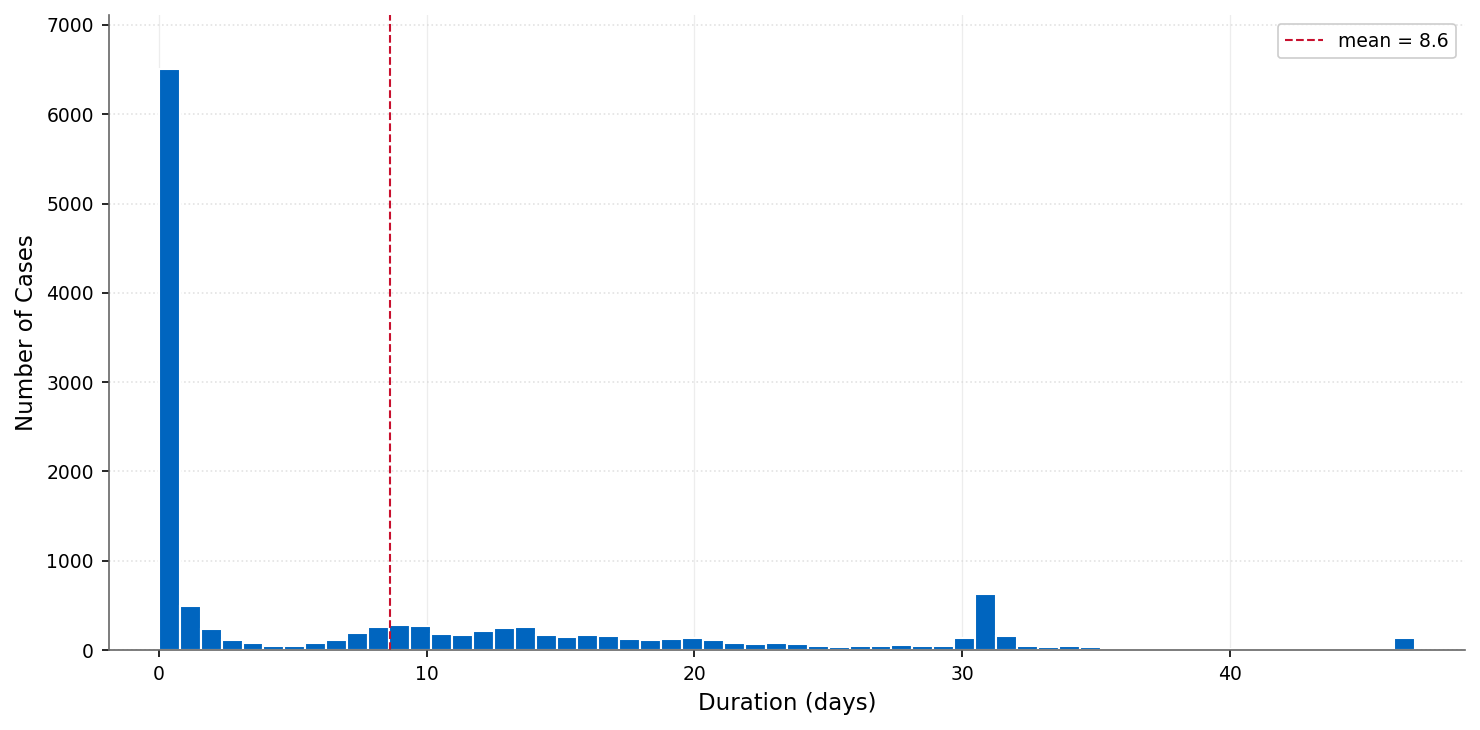

Saved: plots/B_01_case_duration.png


In [23]:
# Get case durations, calculate mean, median and 95th percentile
case_times = df.groupby("case:concept:name")["time:timestamp"].agg(["min", "max"])
case_times["duration_days"] = (case_times["max"] - case_times["min"]).dt.total_seconds() / 86400
print(f"Mean duration:    {case_times['duration_days'].mean():.2f} days")
print(f"Median duration:  {case_times['duration_days'].median():.2f} days")
print(f"95th percentile:  {case_times['duration_days'].quantile(0.95):.2f} days")

# Plot case durations as histogram (0065BF: TUM blue)
fig, ax = plt.subplots(figsize=(10, 5))
case_times["duration_days"].clip(upper=case_times["duration_days"].quantile(0.99)).hist(
    bins=60, ax=ax, color="#0065BF", edgecolor="white"
)
ax.set_xlabel("Duration (days)")
ax.set_ylabel("Number of Cases")

# Mean reference line (C8102E: Highlight red)
_mean_val = case_times["duration_days"].mean()
ax.axvline(_mean_val, color="#C8102E", linewidth=1, linestyle="--", label=f"mean = {_mean_val:,.1f}")
_legend = ax.legend(loc="upper right")
_style_reference_legend(_legend)

# Apply axis styling and add headroom above the tallest bar
_style_non_pie_axes(ax)
_pad_top(ax, fraction=0.04)

# Tighten spacing and save the figure
fig.tight_layout(pad=1.2)
plt.savefig("plots/B_01_case_duration.png", dpi=300)
plt.show()
print("Saved: plots/B_01_case_duration.png")


## 7: Prefix Length Distribution

Each case of length *n* generates *n* training samples before any prefix cap is applied. The 98th percentile is computed after COMPLETE filtering but before outcome-event cutting.

`MAX_PREFIX_LENGTH_FOR_ENCODING` is a data-driven preprocessing parameter, not a documented BPIC 2012 benchmark convention. It is set to the 98th percentile of case length, which yields `MAX_PREFIX_LENGTH_FOR_ENCODING = 42`. The distribution below justifies the value and quantifies how many decision events would be lost by physical truncation. For those affected cases, the diagnostic reports how many events lie between the cap and the final decision event, including the decision event itself.


Mean prefix length: 12.6
Max prefix length: 96
98th percentile: 42.0
Decision events beyond cap: 185 (1.46% of decision cases)
Longest decision length beyond cap: 94 events
Max cap-to-decision gap: 52 events
Mean cap-to-decision gap: 10.2 events
Encoding note: cap prefixes, do not truncate outcome labels


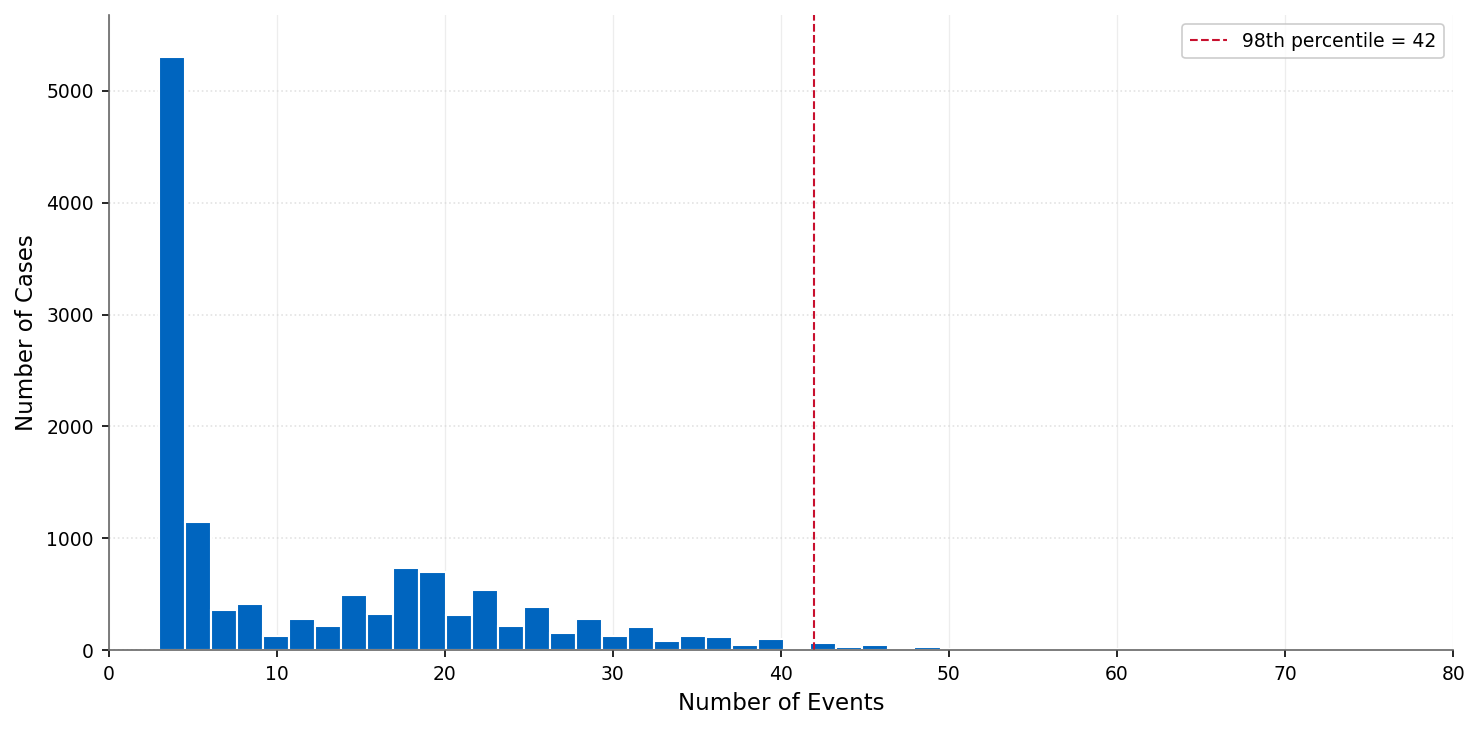

Saved: plots/B_01_prefix_length.png


In [24]:
# Compute the p98 prefix-length cap after COMPLETE filtering and before cutting after the outcome event
df_complete = df[df["lifecycle:transition"] == "COMPLETE"].copy()
prefix_lengths = df_complete.groupby("case:concept:name").size()
p98 = prefix_lengths.quantile(0.98)
cap = int(p98)

# Quantify how often the final decision event would lie beyond the p98 cap
decision_length = last_decision["decision_pos"] + 1
decision_over_cap = decision_length[decision_length > cap] - cap
decision_after_cap = int(decision_over_cap.size)
decision_after_cap_share = decision_after_cap / len(last_decision)
max_gap_to_decision = int(decision_over_cap.max()) if decision_after_cap else 0
mean_gap_to_decision = float(decision_over_cap.mean()) if decision_after_cap else 0.0
longest_decision_length = int(decision_length[decision_length > cap].max()) if decision_after_cap else cap

# Print the summary
print(f"Mean prefix length: {prefix_lengths.mean():.1f}")
print(f"Max prefix length: {prefix_lengths.max()}")
print(f"98th percentile: {p98:.1f}")
print(f"Decision events beyond cap: {decision_after_cap:,} ({decision_after_cap_share:.2%} of decision cases)")
print(f"Longest decision length beyond cap: {longest_decision_length:,} events")
print(f"Max cap-to-decision gap: {max_gap_to_decision:,} events")
print(f"Mean cap-to-decision gap: {mean_gap_to_decision:.1f} events")
print("Encoding note: cap prefixes, do not truncate outcome labels")

# Plot the prefix length
fig, ax = plt.subplots(figsize=(10, 5))
prefix_lengths.hist(bins=60, ax=ax, color="#0065BF", edgecolor="white")

# Mark the 98th-percentile cap for later prefix encoding
ax.axvline(cap, color="#C8102E", linewidth=1, linestyle="--", label=f"98th percentile = {cap:.0f}")
_legend = ax.legend(loc="upper right")
_style_reference_legend(_legend)

# Label axes, constrain the x-range, apply styling
ax.set_xlabel("Number of Events")
ax.set_ylabel("Number of Cases")
ax.set_xlim(0, 80)
_style_non_pie_axes(ax)
_pad_top(ax, fraction=0.02)
fig.tight_layout(pad=1.2)

# Save the figure
plt.savefig("plots/B_01_prefix_length.png", dpi=300)
plt.show()
print("Saved: plots/B_01_prefix_length.png")

## 8: AMOUNT_REQ Distribution

`AMOUNT_REQ` is the only axis available for non-IID client partitioning on BPIC 2012. It plays the same role as `case:RequestedAmount` in BPIC 2017 but without `LoanGoal` to specialize on.

Discrete bin spikes between 5,000 and 25,000 are typical for consumer loans. The percentiles below summarize the requested amount distribution. The partitioning script builds its actual non-zero-amount quintiles with `pd.qcut`. Bin ranges are reported in the following section 9, concerned with approval rates.

AMOUNT_REQ distribution (case-level):
  Min:             0
  Max:        99,999
  Mean:       13,573
  p10:         3,000
  p20:         5,000
  p25:         5,000
  p50:        10,000
  p75:        17,620
  p80:        20,000
  p90:        30,000


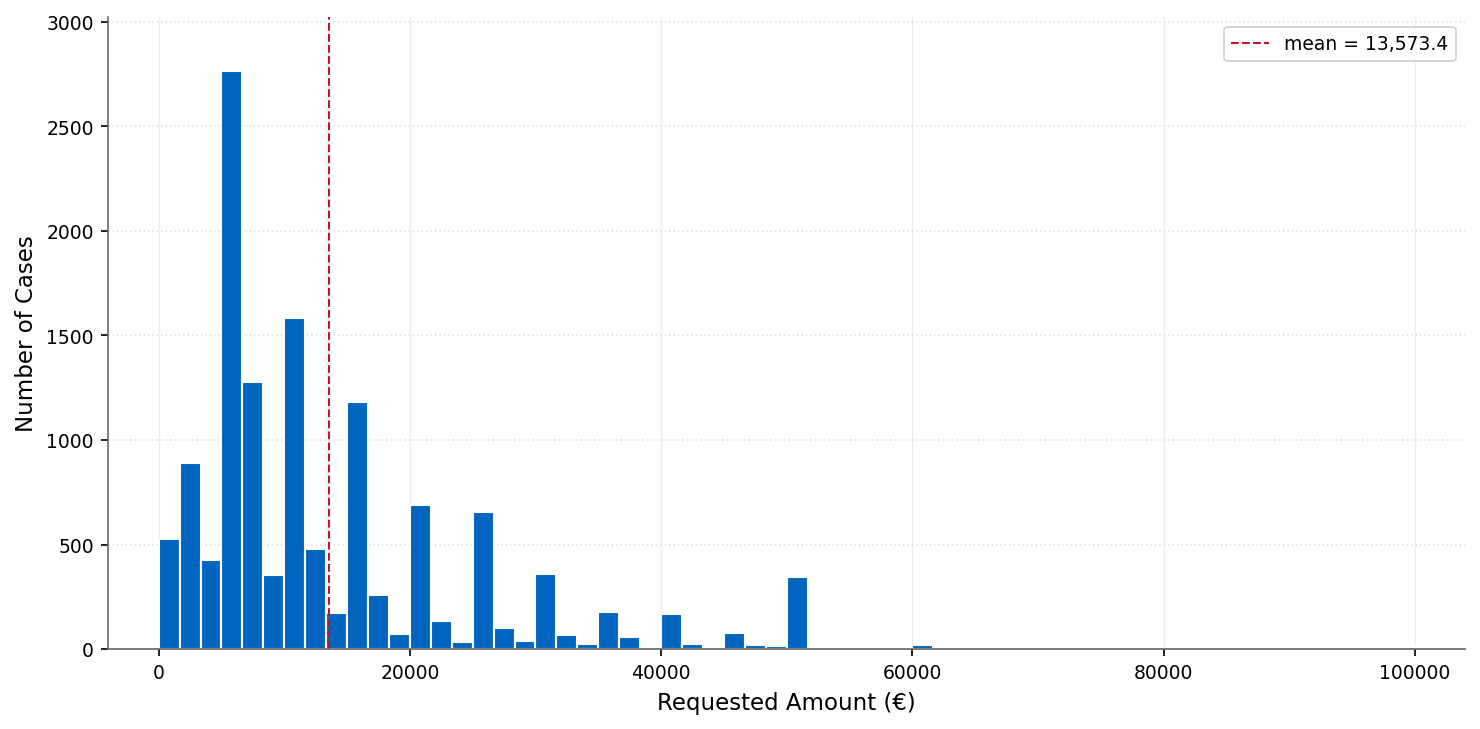

Saved: plots/B_01_requested_amount.png


In [25]:
# Get a unique requested amount for each case
amounts = pd.to_numeric(df.drop_duplicates("case:concept:name")["case:AMOUNT_REQ"], errors="coerce").dropna()
print("AMOUNT_REQ distribution (case-level):")
print(f"  Min:  {amounts.min():>12,.0f}")
print(f"  Max:  {amounts.max():>12,.0f}")
print(f"  Mean: {amounts.mean():>12,.0f}")

# Report distribution quantiles for the requested amount
for p in [10, 20, 25, 50, 75, 80, 90]: print(f"  p{p:<2}:  {amounts.quantile(p / 100):>12,.0f}")

# Plot the requested amount for each case
fig, ax = plt.subplots(figsize=(10, 5))
amounts.hist(bins=60, ax=ax, color="#0065BF", edgecolor="white")
ax.set_xlabel("Requested Amount (€)")
ax.set_ylabel("Number of Cases")

# Mean reference line (C8102E: Highlight red)
_mean_val = amounts.mean()
ax.axvline(_mean_val, color="#C8102E", linewidth=1, linestyle="--", label=f"mean = {_mean_val:,.1f}")
_legend = ax.legend(loc="upper right")
_style_reference_legend(_legend)

# Apply axis styling and add headroom above the tallest bar
_style_non_pie_axes(ax)
_pad_top(ax, fraction=0.04)

# Tighten spacing and save the figure
fig.tight_layout(pad=1.2)
plt.savefig("plots/B_01_requested_amount.png", dpi=300)
plt.show()
print("Saved: plots/B_01_requested_amount.png")


## 9: Approval Rate by AMOUNT_REQ Quintile

`AMOUNT_REQ` is the primary partitioning attribute for BPIC 2012. Cases are grouped into amount quintiles to test whether the approval rate differs in between requested loan sizes.

Truncation cases are dropped, canceled cases are kept as class 0 and `pd.qcut` runs on the non-zero subset. The approval share is computed as approved cases divided by all cases with decision labels in the bin.

 amount_tier  amount_min  amount_max  total  approved  approval_rate
 Q1 (lowest)           1        5000   3732       334       0.089496
          Q2        5001        7500   1572       276       0.175573
          Q3        7680       11500   2324       422       0.181583
          Q4       11612       20000   2691       664       0.246748
Q5 (highest)       20072       99999   2368       550       0.232264

Overall approval share (non-zero): 0.177


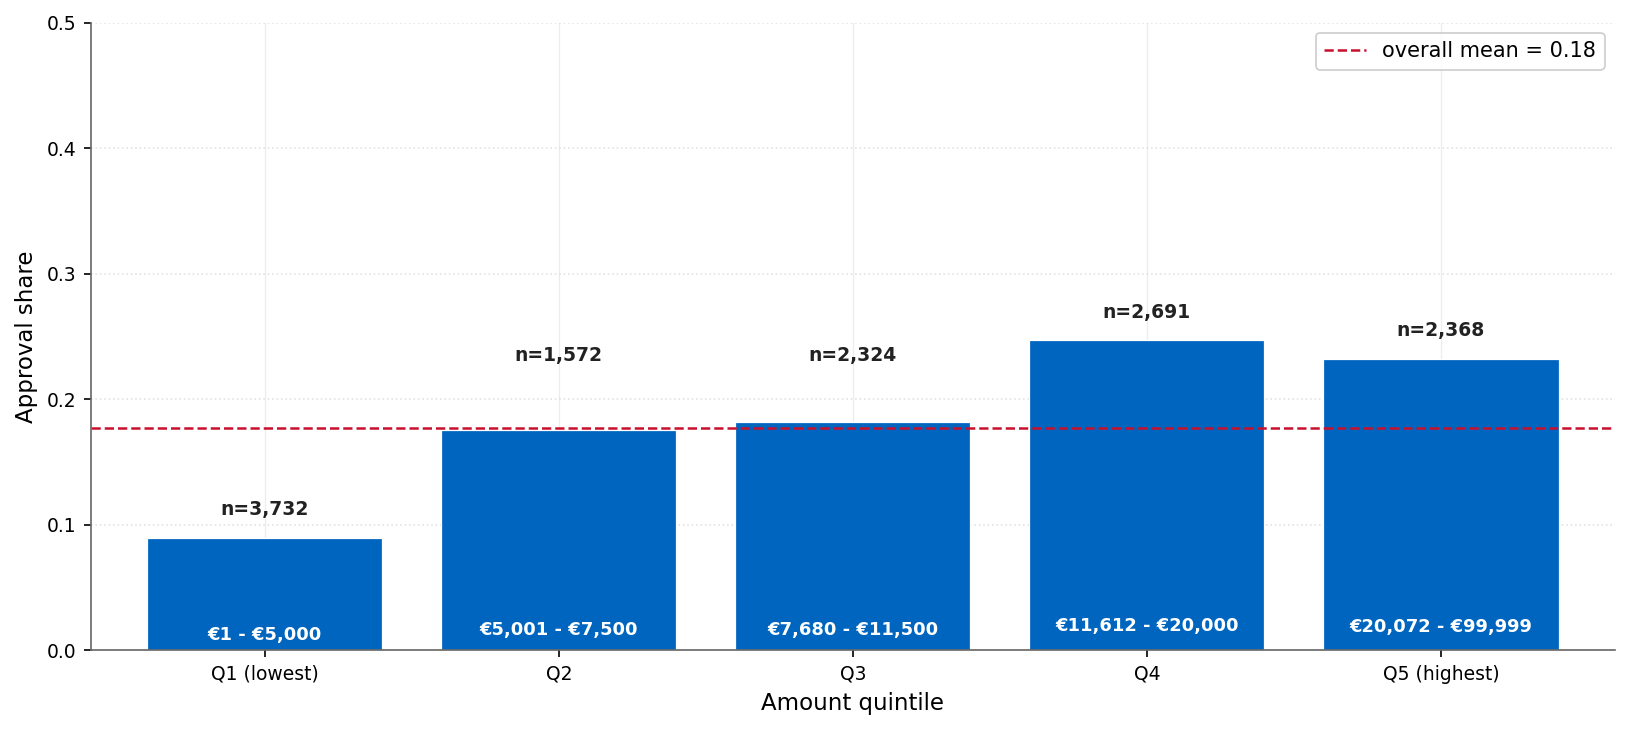

Saved: plots/B_01_approval_by_amount_tier.png


In [26]:
# Define outcome activities
APPROVED, DECLINED, CANCELLED = "A_APPROVED", "A_DECLINED", "A_CANCELLED"
TERMINAL_OUTCOMES = [APPROVED, DECLINED, CANCELLED]

# Apply the COMPLETE filter before resolving BPIC 2012 outcomes
approval_base = df[df["lifecycle:transition"] == "COMPLETE"].copy()

# Build a terminal outcome per case by taking the last terminal event
last_outcome = (
    approval_base[approval_base["concept:name"].isin(TERMINAL_OUTCOMES)]
    .sort_values("time:timestamp")
    .groupby("case:concept:name")["concept:name"].last()
    .reset_index().rename(columns={"concept:name": "outcome"})
)

# Keep one row per case, drop truncation cases and retain canceled as class 0
case_amt = (
    df.drop_duplicates("case:concept:name")[["case:concept:name", "case:AMOUNT_REQ"]]
    .assign(amount=lambda d: pd.to_numeric(d["case:AMOUNT_REQ"], errors="coerce"))
)
meta = case_amt.merge(last_outcome, on="case:concept:name", how="inner")
meta["approved"] = (meta["outcome"] == APPROVED).astype(int)

# Split non-zero AMOUNT_REQ values into quintiles with pd.qcut()
nonzero = meta.loc[meta["amount"] > 0].copy()
nonzero["amount_quintile"] = pd.qcut(nonzero["amount"], q=5, labels=False, duplicates="drop").astype(int)

# Apply Q1 (lowest) and Qn (highest) boundary labels for the bar chart
n_tiers = nonzero["amount_quintile"].nunique()
tier_labels = {i: f"Q{i + 1}" for i in range(n_tiers)}
tier_labels[0] = "Q1 (lowest)"
tier_labels[n_tiers - 1] = f"Q{n_tiers} (highest)"
nonzero["amount_tier"] = nonzero["amount_quintile"].map(tier_labels)

# Aggregate per quintile, with canceled included in the denominator
tier_stats = (
    nonzero.groupby(["amount_quintile", "amount_tier"], observed=True)
    .agg(total=("approved", "size"), approved=("approved", "sum"), amount_min=("amount", "min"), amount_max=("amount", "max"))
    .assign(approval_rate=lambda d: d["approved"] / d["total"])
    .reset_index()
    .sort_values("amount_quintile")
)
overall_mean = float(nonzero["approved"].mean())

# Print the per-quintile summary
print(tier_stats[["amount_tier", "amount_min", "amount_max", "total", "approved", "approval_rate"]].to_string(index=False))
print(f"\nOverall approval share (non-zero): {overall_mean:.3f}")

# Plot approval share by amount quintile, with the amount range placed inside each bar
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(tier_stats["amount_tier"], tier_stats["approval_rate"], color="#0065BF", edgecolor="white", linewidth=0.6)

# Place the amount range inside the bar and the case count above it
for bar, row in zip(bars, tier_stats.itertuples(index=False)):
    x = bar.get_x() + bar.get_width() / 2
    ax.text(
        x, bar.get_height() * 0.05,
        f"€{row.amount_min:,.0f} - €{row.amount_max:,.0f}",
        ha="center", va="bottom", fontsize=8.6, fontweight="bold", color="white",
    )
    y = bar.get_height() + 0.015
    if overall_mean - 0.06 < bar.get_height() < overall_mean + 0.025:
        y = overall_mean + 0.05
    ax.text(x, y, f"n={int(row.total):,}", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#222222")

# Reference line for the overall mean approval share over non-zero cases
mean_line = ax.axhline(overall_mean, color="#C8102E", linewidth=1.2, linestyle="--", label=f"overall mean = {overall_mean:.2f}")
_legend = ax.legend(handles=[mean_line], loc="upper right", frameon=True, fontsize=10)
_style_reference_legend(_legend)

# Finalize axis labels and layout
ax.set_xlabel("Amount quintile")
ax.set_ylabel("Approval share")
ax.set_ylim(0, max(0.5, float(tier_stats["approval_rate"].max()) * 1.30))
_style_non_pie_axes(ax)
fig.tight_layout(pad=1.2)

# Save the figure
plt.savefig("plots/B_01_approval_by_amount_tier.png", dpi=300)
plt.show()
print("Saved: plots/B_01_approval_by_amount_tier.png")

## 10: Resource Cardinality

`org:resource` is a candidate embedding feature, identical in `role` to its BPIC 2017 counterpart. Cardinality is much smaller in BPIC 2012 (~68 distinct resources vs. ~149 in BPIC 2017).

The smaller vocabulary lowers the embedding parameter count and the share of unseen-at-test-time tokens but carries less information per resource.

In [27]:
# Get unique resources and their counts
resources = df["org:resource"].dropna()
n_res = resources.nunique()
print(f"Distinct resources: {n_res}")
print(f"\nTop 20 resources by event count:")
print(resources.value_counts().head(20).to_string())
print(f"\nShare of events from the top resource:    {resources.value_counts().iloc[0] / len(resources):.1%}")
print(f"Share of events from the top 5 resources: {resources.value_counts().head(5).sum() / len(resources):.1%}")

Distinct resources: 68

Top 20 resources by event count:
org:resource
112      45687
11169     7825
10138     7690
11181     7551
10861     7382
10609     7049
10913     6842
11189     6778
11180     6777
11119     6712
10909     6558
10972     6316
11203     6294
11201     5995
10982     5989
11122     5591
11049     5441
10629     4975
10910     4787
11259     4638

Share of events from the top resource:    18.7%
Share of events from the top 5 resources: 31.2%


## 11: Temporal Distribution of Case Starts

Shows how many new loan applications were submitted each month during the BPIC 2012 observation window (~5.5 months, October 2011 to mid-March 2012). The temporal train/val/test split (60/20/20 by case start time) operates on this distribution.

The window is much shorter than BPIC 2017's 13 months. The test set covers roughly the last six weeks of the log, which limits the diversity of patterns the model is evaluated against.

time:timestamp
2011-10    2393
2011-11    2940
2011-12    2122
2012-01    2747
2012-02    2885
Freq: M


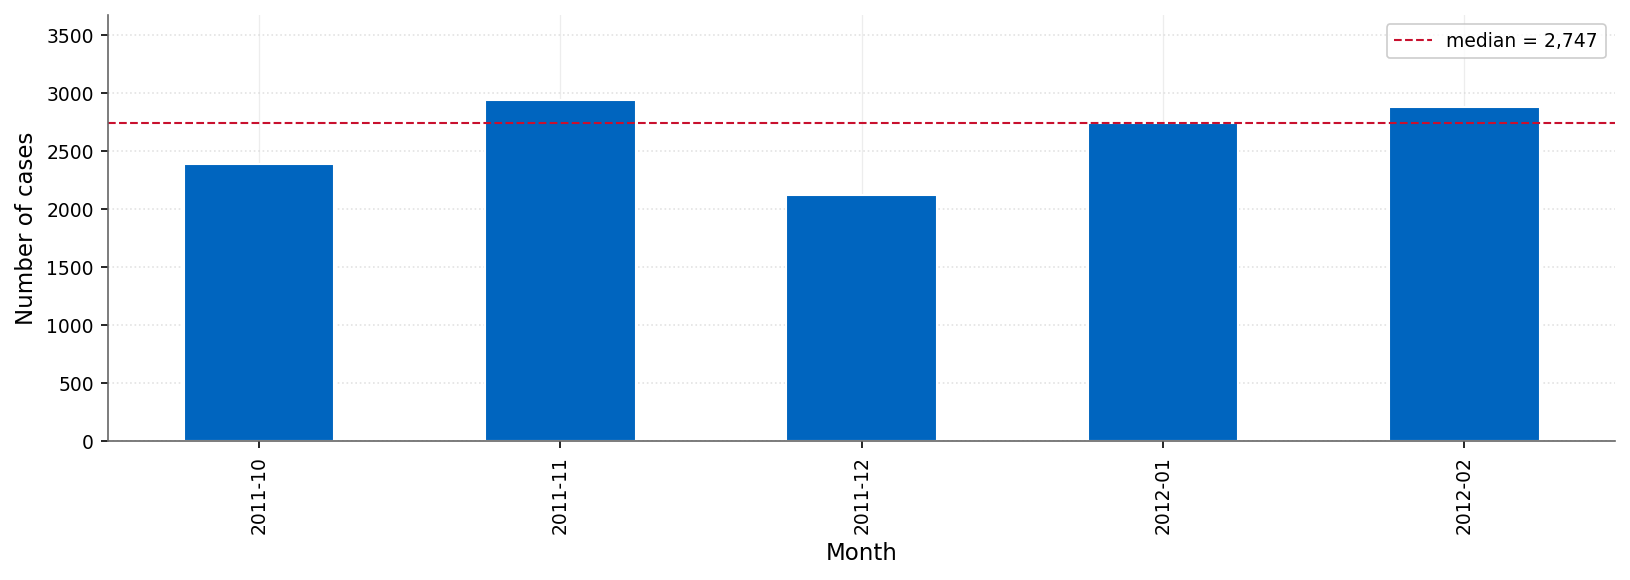

In [28]:
# Find the temporal distribution of case starts
case_starts = df.groupby("case:concept:name")["time:timestamp"].min()
monthly_starts = (case_starts.dt.tz_localize(None).dt.to_period("M").value_counts().sort_index())
print(monthly_starts.to_string())

# Plot the temporal distribution by month
fig, ax = plt.subplots(figsize=(11, 4))
monthly_starts.plot(kind="bar", ax=ax, color="#0065BF", edgecolor="white", legend=False)
_median_val = float(monthly_starts.median())
_median_line = ax.axhline(_median_val, color="#C8102E", linewidth=1, linestyle="--", label=f"median = {_median_val:,.0f}")
_legend = ax.legend(handles=[_median_line], loc="upper right")
_style_reference_legend(_legend)
ax.set_ylim(0, monthly_starts.max() * 1.25)
ax.set(xlabel="Month", ylabel="Number of cases")

# Finalize axis labels, layout and save
_style_non_pie_axes(ax)
fig.tight_layout(pad=1.2)
plt.savefig("plots/B_01_case_starts_by_month.png", dpi=300)
plt.show()

## 12: MD5 Hash of the Dataset File

Reproducibility requires that analysis, plots and results reported in this thesis can be retraced to the exact same input file. Even a partial re-download or a silent encoding change could change the behavior of the system and propagate to the final results.

To guard against this, the MD5 hash of the uncompressed `BPI_Challenge_2012.xes` file is recorded below. The hash, the file size in bytes and the source DOI are also logged in the repository `README.md`.


In [29]:
import hashlib
from pathlib import Path

# MD5 hash of a file, computed in 1 MB chunks
def file_md5(path, chunk_size=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""): h.update(chunk)
    return h.hexdigest()

xes_path = Path("BPI Challenge 2012/BPI_Challenge_2012.xes")

print(f"File:    {xes_path.name}")
print(f"Size:    {xes_path.stat().st_size:,} bytes")
print(f"MD5:     {file_md5(xes_path)}")

File:    BPI_Challenge_2012.xes
Size:    74,100,050 bytes
MD5:     b815ef03ebae63407bc09de191a748f6


## 13: Cross-Dataset Comparison Summary

Aggregate the headline numbers from this notebook and the BPIC 2017 EDA into a single table for the thesis. The same institution, smaller log, fewer attributes and inverse approval skew make BPIC 2012 a useful generalization check.

The outcome-label alignment table at the bottom maps BPIC 2012 terminal events to the shared three-class schema.


In [30]:
# HELPER: Print compact left-aligned text tables
def print_left_aligned_table(table: pd.DataFrame) -> None:
    rows = [table.columns.tolist()] + table.astype(str).values.tolist()
    widths = [max(len(row_temp[i]) for row_temp in rows) for i in range(len(rows[0]))]

    for row_temp in rows:
        print("  ".join(str(value).ljust(widths[i]) for i, value in enumerate(row_temp)))


# Build a compact side-by-side dataset summary
summary = pd.DataFrame(
    {
        "Metric": [
            "Cases", "Events", "Time window", "Activities", "Lifecycle handling", "Resources",
            "Case attributes", "Offer attributes", "Approved label", "Denied label", "Cancelled label",
        ],
        "BPIC 2017": [
            "31,509", "1,202,267", "2016-01 to 2017-02 (13 months)",
            "26", "lifecycle-aware activity_token", "~149",
            "RequestedAmount, LoanGoal, ApplicationType",
            "CreditScore, MonthlyCost, OfferedAmount, NumberOfTerms",
            "O_Accepted", "A_Denied", "A_Cancelled",
        ],
        "BPIC 2012": [
            f"{n_cases:,}", f"{n_events:,}",
            f"{df['time:timestamp'].min().date()} to {df['time:timestamp'].max().date()}",
            f"{df['concept:name'].nunique()}", "COMPLETE filter, then activity_token", f"{n_res}",
            "AMOUNT_REQ", "none",
            "A_APPROVED", "A_DECLINED", "A_CANCELLED",
        ],
    }
)

print("\nBPIC 2017 vs. BPIC 2012 DATASET SUMMARY")
print("-" * 120)
print_left_aligned_table(summary)

# Build outcome-label alignment for the multiclass outcome head
outcome_alignment = pd.DataFrame(
    [
        ("A_APPROVED", "O_Accepted", 2, "accepted decision"),
        ("A_DECLINED", "A_Denied", 1, "denied decision"),
        ("A_CANCELLED", "A_Cancelled", 0, "cancelled decision"),
    ],
    columns=["BPIC 2012", "Shared schema label", "class_id", "interpretation"],
)

print("\nOUTCOME LABEL ALIGNMENT (used by the outcome head)")
print("-" * 120)
print_left_aligned_table(outcome_alignment)


BPIC 2017 vs. BPIC 2012 DATASET SUMMARY
------------------------------------------------------------------------------------------------------------------------
Metric              BPIC 2017                                               BPIC 2012                           
Cases               31,509                                                  13,087                              
Events              1,202,267                                               262,200                             
Time window         2016-01 to 2017-02 (13 months)                          2011-10-01 to 2012-03-14            
Activities          26                                                      24                                  
Lifecycle handling  lifecycle-aware activity_token                          COMPLETE filter, then activity_token
Resources           ~149                                                    68                                  
Case attributes     RequestedAmount, LoanGoal, 